# 臺灣銀行委辦 AI 人才進階訓練

> 機器學習（一），2026-04-23

[郭耀仁](https://hahow.in/@tonykuoyj?tr=tonykuoyj) | <yaojenkuo@ntu.edu.tw>

## 目錄

- 機器學習入門（P.3）
- Scikit-Learn 入門（P.40）
- 資料預處理（P.46）
- 降維（P.52）
- 迴歸模型（P.69）
- 隨堂練習（P.84）

## 機器學習入門

## 資料科學、機器學習、深度學習與人工智慧

- 資料科學是一門涵蓋多個學科的領域，結合了數學、統計學和電腦科學，藉此針對大量資料進行分析，透過資料獲取有意義之資訊，進而對企業的營運、獲利產生助益。
- 機器學習是資料科學研究流程的其中一個環節：模型，經過訓練後建立一個能夠針對無標籤資料預測的函數。
- 深度學習是機器學習的一個子集合，是一種不需要使用者直接決定特徵的最適化方法，改由深度學習的結構間接決定。
- 人工智慧是機器學習的母集合，是一門希望讓軟體程式模擬或複製人類認知任務的能力，具備人工智慧的軟體可以分析資料、辨識符號、與人類對話等。

## 資料科學的研究流程（循環、非線性）

- 資料載入。
- 資料清理。
- 資料轉換。
- 資料視覺化。
- 模型。
- 溝通。

## 資料科學的研究流程示意圖

![](0001.png)

## 機器學習的定義：三個要素、一個但書

> A computer program is said to learn from experience E with respect to some class of tasks T and performance measure P if its performance at tasks in T, as measured by P, improves with experience E.

來源：[Machine Learning, Tom Mitchell, McGraw Hill, 1997](http://www.cs.cmu.edu/~tom/mlbook.html)

## 傳統透過電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/3pojPXW.png?1)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定規則 $w$ 以及資料 $X$，我們就可以定義出函數 $f$ 生成答案 $y$

\begin{equation}
y = f(X;w) = Xw
\end{equation}

## 以機器學習的電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/YunyLd7.png)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定答案 $y$ 以及資料 $X$，機器學習的電腦程式在最小化損失函數 $J$ 的前提下生成規則 $w$，進而獲得預測 $\hat{y}$

\begin{equation}
\text{choose} \; w \in \{w^1, w^2, ..., w^n\} \\
\text{where} \; w \; \text{minimizes} \; J(w) \\
\text{subject to} \; \hat{y} = h(X; w) = Xw \\
\text{where} \; J(w) \; \text{measures the loss between} \; y \; \text{and} \; \hat{y} \\
\end{equation}

## 預測數值時最常見的損失函數 $J$

最小化均方誤差（Mean squared error）。

\begin{align}
\operatorname*{arg\,min}_w \;  J(w) =  \frac{1}{m} \sum_i^m (y_i - \hat{y_i})^2
\end{align}

## 預測類別時最常見的損失函數 $J$

最小化預測錯誤個數。

\begin{align}
\operatorname*{arg\,min}_w \; J(w) = \sum_i n(E_i) \\ \text{ where } E_i \; \text{represents the occurrence of } y_i \neq \hat{y_i}
\end{align}

## 機器學習的資料表達：特徵矩陣與目標陣列

- 外型 `(m, n)` 的特徵矩陣 $X$
- 外型 `(m,)` 的目標陣列 $y$

In [1]:
import matplotlib.pyplot as plt

def plot_X_y():
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.axis('equal')
    # Draw features matrix
    ax.vlines(range(6), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=0, xmax=5, lw=1)
    font_prop = dict(size=12, family='monospace')
    ax.text(-1, -1, "Feature Matrix ($X$)", size=14)
    ax.text(0.1, -0.3, r'n_features $\longrightarrow$', **font_prop)
    ax.text(-0.1, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    # Draw labels vector
    ax.vlines(range(8, 10), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=8, xmax=9, lw=1)
    ax.text(7, -1, "Target Array ($y$)", size=14)
    ax.text(7.9, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    ax.set_ylim(10, -2)
    plt.show()

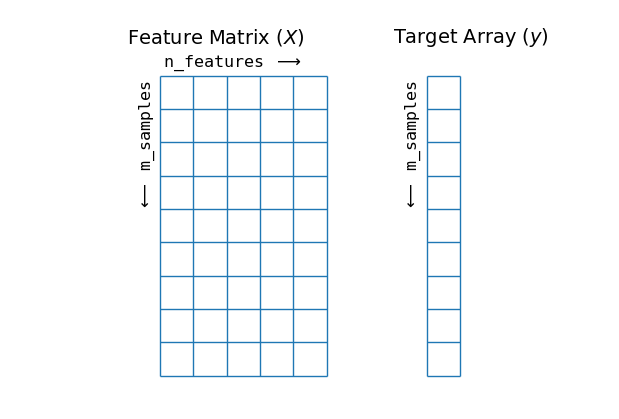

In [2]:
# 來源：<https://jakevdp.github.io/PythonDataScienceHandbook>
plot_X_y()

## 什麼是模型

- 模型（Model）是一個類似於「函數」的概念，由參數與運算組成。
- 模型的參數以及運算可以透過不同的方式生成，生成方式包含規則敘述與歷史資料訓練。
    - 透過規則敘述生成參數以及運算，稱為基於規則的模型（Rule-based model）或稱專家模型。
    - 透過歷史資料訓練生成參數以及運算，稱為基於演算法的模型（Algorithm-based model）或稱基於機器學習的模型。
- 不同模型除了相互比較，也可以與基準（Baseline）模型比較，常用來作為基準模型的像是基於隨機的黑猩猩模型或稱虛假模型（Dummy model），像是以投擲硬幣、骰子或者射飛鏢來決定模型的輸出。

## 可以採用哪種模型解決問題

- 採用基於規則的模型：
    - 問題能用人類語言描述邏輯、撰寫規則。
    - 答案不能容忍誤差。
- 採用基於機器學習的模型：
    - 問題非領域專家不容易描述邏輯、撰寫規則。
    - 答案能夠容忍誤差。

## 可以採用哪種模型解決問題（續）

- 採用基於規則的模型：給定整數判斷它是否為奇數、偶數或者質數。
- 採用基於機器學習的模型：給定圖片判斷是貓或狗、給定房屋資訊預測房價。

## 基於機器學習的模型可再分為

- 監督式學習：訓練資料中具備已實現的數值或標籤。
    - 迴歸：數值預測的任務。
    - 分類：類別預測的任務。
- 非監督式學習：訓練資料中「不」具備已實現的數值或標籤。

## 數值預測的任務：迴歸模型

- 「數值預測」是「監督式學習」的其中一種應用類型。
- 預測的目標陣列 $y$ 屬於連續型數值變數。
- 更常被稱為「迴歸模型」。

## 類別預測的任務：分類器

- 「類別預測」是「監督式學習」的其中一種應用類型。
- 預測的目標陣列 $y$ 屬於離散型的類別變數。
- 更常被稱為「分類器」。

## 機器學習模型是基於最小化損失函數所建立

- 透過相同的損失函數評估表現。
- 差別在於究竟要比對哪一組目標陣列 $y$。

## 找尋係數向量的依據

基於最小化 $y^{(train)}$ 與 $\hat{y}^{(train)}$ 之間的誤差。

## 數值預測任務以均方誤差（Mean squared error, MSE）來表示

\begin{equation}
\operatorname*{arg\,min}_w \; \text{MSE}^{(train)} = \frac{1}{m}\sum_{i}^{m}{(y^{(train)}_i - \hat{y_i}^{(train)})^2}
\end{equation}

## 類別預測任務是以誤分類數（Error）來表示

\begin{align}
\operatorname*{arg\,min}_w \; \text{Errors}^{(train)} = \sum_i n(E^{(train)}_i) \\ \text{ where } E^{(train)}_i \; \text{represents the occurrence of } y^{(train)}_i \neq \hat{y_i}^{(train)}
\end{align}

## 評估迴歸模型的表現同樣是比較預測目標陣列與實際目標陣列之間的誤差

但是改為驗證資料或測試資料的目標陣列。

\begin{equation}
\text{MSE}^{(valid)} = \frac{1}{m}\sum_{i}^{m}{(y^{(valid)}_i - \hat{y_i}^{(valid)})^2}
\end{equation}

## 評估分類器的表現評估以誤分類數衡量

但是改為驗證資料或測試資料的目標陣列。

\begin{align}
\text{Errors}^{(valid)} = \sum_i n(E^{(valid)}_i) \\ \text{ where } E^{(valid)}_i \; \text{represents the occurrence of } y^{(valid)}_i \neq \hat{y_i}^{(valid)}
\end{align}

## 關於訓練、驗證與測試

- 機器學習專案中的訓練、驗證來自具備已實現數值或標籤資料集。
- 測試則來自未實現數值或標籤資料集。
- 在從未見過的測試資料上之表現將決定它是否會被部署到正式環境開始運作。

## 誤差來源可以大抵分為

- 訓練誤差（Training error）
- 測試誤差（Testing error）

## 訓練與測試誤差

- 在已實現、具備目標值或標籤的訓練、驗證資料上表現良好，表示它的訓練誤差小。
- 在尚未實現、不具備目標值或標籤的測試資料上表現良好，表示它的測試誤差小（又稱為泛化能力強）。
- 不過在現實世界中，處於訓練與驗證階段時對於測試資料是一無所知的，如何在只能接觸到訓練與驗證資料時去降低測試誤差？

## 訓練、驗證與測試資料的 i.i.d. 假設

- 資料中每一筆觀測值彼此獨立（Independent）。
- 訓練、驗證與測試資料來自同樣分佈（Identically distributed）的母體。

## 機器學習演算方法的目標

1. 減少訓練誤差。
2. 減少訓練誤差與測試誤差的間距。

## 減少訓練誤差的具體做法

- 增加梯度遞減的訓練次數。
- 透過交叉驗證（Cross validation）的技巧消弭訓練與驗證資料切割所造成的誤差。
- 增加特徵矩陣的欄位。

## 減少訓練誤差與測試誤差的間距

引用正規化（Regularization）的技巧。

## 藉由增加梯度遞減的訓練次數減少訓練誤差的做法是直觀的

隨機初始化的 $w$ 的訓練誤差是高的，隨著訓練次數增加而漸漸減少。

## 交叉驗證

- 希望避免某個隨機狀態劃分出了不夠均勻的訓練和驗證資料。
- 將資料拆分為 `k` 個不重複的子集合，進而可以在這些子集合上重複進行訓練和驗證。
- 取平均值來評估誤差。

## 更多減少訓練誤差的方式

- 超參數（Hyperparameter）調校。
- 變換其他機器學習模型。
- 製造衍生變數（特徵工程）。
- ...等。

## 減少訓練誤差與測試誤差的間距

- 減少訓練誤差的過程，很有可能伴隨而來的是驗證或測試誤差的升高。
- 模型對於訓練資料過於熟悉，而降低了它的泛化能力。
- 這樣的狀態我們稱之為「過度配適」（Overfitting）。

## 模型不同的配適狀態

![](0003.png)

## Scikit-Learn 入門

## 什麼是 Scikit-Learn

> Scikit-learn 是 Python 機器學習的第三方模組，透過它可以進行監督式以及非監督式學習，提供了模型訓練、資料預處理、模型選擇以及模型評估等功能。

來源：<https://scikit-learn.org>

## （沒什麼用的冷知識）Scikit-Learn 是最受歡迎的 SciKit(SciPy Toolkit)

- Scikit-Learn 與 Scikit-Image 是兩個最受歡迎、維護最良善的 Scikits
- 還有眾多其他的 Scikits

來源：<https://projects.scipy.org/scikits.html>

## 根據說明文件的範例載入

多數時候我們使用 Scikit-Learn 中的特定類別或函數，因此以 `from sklearn import FUNCTION/CLASS` 載入特定類別或函數，而非 `import sklearn`

來源：<https://scikit-learn.org/stable/getting_started.html>

## 為什麼選擇 Scikit-Learn

- 簡潔、一致且設計良善的應用程式介面設計，只要理解基礎用法和語法，就能延伸切換到其他的演算法或模型。
- 文件撰寫完整而豐富。
- 維護良善。

## Scikit-Learn 應用程式介面設計原則

1. 一致性。
2. 可檢查性。
3. 不擴增新類別。
4. 可組合性。
5. 合理預設參數。

## 資料預處理

## 轉換器與預測器是 Scikit-Learn 所創造最重要的兩種類別

1. **轉換器：用來預處理資料**。
2. 預測器：用來訓練模型、生成規則 $w$

## 使用 Scikit-Learn 轉換器的標準步驟

1. 準備欲轉換的特徵矩陣 $X$ 或目標陣列 $y$
2. 建立轉換器類別的物件。
3. 將欲轉換的特徵矩陣 $X$ 或目標陣列 $y$ 輸入 `transformer.fit_transform()`
4. 檢查轉換結果。

## 使用 Scikit-Learn 轉換器 `PolynomialFeatures`

生成一個指定次方數的特徵多項式矩陣。

In [5]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

csv_url = "https://raw.githubusercontent.com/yaojenkuo/ml-newbies/master/player_stats.csv"
player_stats = pd.read_csv(csv_url)
X = player_stats["heightMeters"].values.reshape(-1, 1) # step 1
polynomial_features = PolynomialFeatures()             # step 2
X_transformed = polynomial_features.fit_transform(X)   # step 3
print(X_transformed[:5])                               # step 4

[[1.     2.03   4.1209]
 [1.     2.11   4.4521]
 [1.     2.06   4.2436]
 [1.     1.9    3.61  ]
 [1.     1.98   3.9204]]


## 使用 Scikit-Learn 轉換器 `StandardScaler`

生成一個經過 z-score 標準化的特徵矩陣。

\begin{equation}
z = \frac{x - \mu}{\sigma}
\end{equation}

In [6]:
from sklearn.preprocessing import StandardScaler

X = player_stats["heightMeters"].values.reshape(-1, 1) # step 1
standard_scaler = StandardScaler()                     # step 2
X_transformed = standard_scaler.fit_transform(X)       # step 3
print(X_transformed[:5])                               # step 4

[[ 0.48558003]
 [ 1.42770829]
 [ 0.83887812]
 [-1.04537841]
 [-0.10325014]]


## 複習：Scikit-Learn 應用程式介面設計原則

- 一致性：每個轉換器類別都有 `fit_transform()` 方法。
- 合理預設參數：每個轉換器、預測器都可以用預設參數建立物件。
- 可檢查性：每個轉換器或預測器都有屬性讓使用者檢視轉換或預測的規則。

In [7]:
print(polynomial_features.degree)
print(standard_scaler.mean_)
print(standard_scaler.scale_)

2
[1.9887674]
[0.08491413]


## 降維

## 什麼是降維（Dimensionality reduction）

- 大量高維度數據的分析提供更多訊息量，但其中可能伴隨著一些雜訊，或不可信賴的異常值和離群值，因而導致分析偏誤，進而影響到最終對分析結果的決策及判斷。
- 降維希望在除去不必要訊息的同時，盡可能保留原始數據中的有用訊息，以減輕分析過程中的時間和成本負擔。

## 主成分分析

- 在統計學及機器學習領域中，主成分分析（Principal Component Analysis, PCA）為一種常用的降低數據維度的手法。由英國數學家 Karl Pearson 於 1901 年提出，是一種歷史悠久且相對容易運用的降維度、去關聯性的方法。
- 主要的核心概念是用最少的維度來呈現原本高維度數據的訊息：將原本 p 維的特徵（features）以 k 維的線性組合來表達（k < p），藉由找到的 k 維新特徵，能夠捕捉原本 p 維數據中的大部分特性來解釋數據。換言之，希望能夠在盡量保有原始數據訊息的情況下，以更精簡化的形式來呈現原始數據。

## 主成分分析的目標

- 找到一個或一個以上的投影軸（向量），將資料點線性投影到這些軸上後，使得資料有最大的變異量。
- 假設 $v$ 就是我們找到的投影軸，$x_i$ 是資料點，$C$ 為共變異數矩陣。

\begin{align}
\sigma^2 &= \frac{1}{m}\sum_{i=1}^{m}(v^Tx_i - \mu)^2 = \frac{1}{m}\sum_{i=1}^{m}(v^Tx_i - 0)^2 = \frac{1}{m}\sum_{i=1}^{m}(v^Tx_i)^2 \\
&= \frac{1}{m}\sum_{i=1}^{m} (v^Tx_i)(v^Tx_i)^T = \frac{1}{m} v^T ( \sum_{i=1}^{m} (x_i x_i^T) ) v = v^TCv \\
\end{align}

## 偏微求解

- $v$ 即為特徵向量（eigenvectors）
- $\lambda$ 即為特徵值（eigenvalues）

\begin{equation}
v^* = \operatorname*{arg\,max}_v \; v^TCv \\
\mathcal{L}(v, \lambda) = v^TCv - \lambda(v^Tv - 1) \\
\frac{\partial \mathcal{L}}{\partial v} = 2v^TC - 2 \lambda v^T = 0 \\
\frac{\partial \mathcal{L}}{\partial \lambda} = v^v - 1 = 0 \\
Cv = \lambda v
\end{equation}

## 主成分分析的步驟

- 對數據做標準化。
- 建立共變異數矩陣。
- 分解共變異數矩陣為特徵向量及特徵值。
- 排序特徵值並且以該順序排列特徵向量。
- 映射數據至主成分。

## 對數據做標準化

In [8]:
def standardize(X):
    mean_X = np.mean(X, axis=0)
    std_X = np.std(X, axis=0)
    return (X - mean_X) / std_X

## 建立共變異數矩陣

In [9]:
def covariance_matrix(X):
    m = X.shape[0]
    X_T = np.transpose(X)
    X_T_dot_X = X_T.dot(X)
    return X_T_dot_X / (m - 1)

## 分解共變異數矩陣為特徵向量及特徵值

In [10]:
from numpy.linalg import eigh

def get_eig_vals_vecs(X):
    X_standard = standardize(X)
    cov_mat = covariance_matrix(X_standard)
    eig_vals, eig_vecs = eigh(cov_mat)
    return eig_vals, eig_vecs

## 排序特徵值並且以該順序排列特徵向量

In [11]:
def get_principal_components(eigen_vals, eigen_vecs, k=2):
    sort_index = np.argsort(eigen_vals)[::-1]
    principal_components = eigen_vecs[:,sort_index]
    return principal_components[:, 0:k]

## 映射數據至主成分

In [12]:
def project_with_principal_components(X, principal_components):
    X_proj = X.dot(principal_components)
    return X_proj

## 呼叫定義好的主成分分析函數

In [13]:
X = player_stats[["heightMeters", "weightKilograms", "ppg", "rpg", "apg", "bpg", "mpg", "spg"]].values
eig_vals, eig_vecs = get_eig_vals_vecs(X)
principal_components = get_principal_components(eig_vals, eig_vecs)
print(principal_components)

[[-0.09356129 -0.5405206 ]
 [-0.13818604 -0.50663074]
 [-0.45920451  0.11706303]
 [-0.42149541 -0.26861885]
 [-0.34079429  0.36918406]
 [-0.28699409 -0.38382527]
 [-0.47404909  0.13309185]
 [-0.40049325  0.25292445]]


In [14]:
print(project_with_principal_components(standardize(X), principal_components))

[[ 1.44589649 -1.25240962]
 [-2.02798202 -2.67058885]
 [-2.63744516 -1.51229563]
 ...
 [ 3.57844588 -2.63263971]
 [-0.87499066 -1.85178204]
 [-0.09906745 -2.52969675]]


## 與 Scikit-Learn 的 `PCA` 類別對照

In [15]:
from sklearn.decomposition import PCA

X = player_stats[["heightMeters", "weightKilograms", "ppg", "rpg", "apg", "bpg", "mpg", "spg"]]
standardize_X = standardize(X)
pca = PCA(n_components=2)
pca.fit(standardize_X)
print(pca.components_.T)

[[ 0.09356129 -0.5405206 ]
 [ 0.13818604 -0.50663074]
 [ 0.45920451  0.11706303]
 [ 0.42149541 -0.26861885]
 [ 0.34079429  0.36918406]
 [ 0.28699409 -0.38382527]
 [ 0.47404909  0.13309185]
 [ 0.40049325  0.25292445]]


In [16]:
print(pca.fit_transform(standardize_X))

[[-1.44589649 -1.25240962]
 [ 2.02798202 -2.67058885]
 [ 2.63744516 -1.51229563]
 ...
 [-3.57844588 -2.63263971]
 [ 0.87499066 -1.85178204]
 [ 0.09906745 -2.52969675]]


## 主成分分析的總結

- 精簡化（parsimony）：用較少的主成分來取代原本的高維度特徵。
- 代表性（representation）：主成分保有原本特徵的訊息。
- 去相關（decorrelation）：主成分分數（即新特徵）彼此之間無線性相關。

## 迴歸模型

## 使用基於最小化損失函數的機器學習模型解決數值預測的任務

創造一個 $h$ 函數可以將無標籤資料 $x$ 作為輸入，以係數 $w$ 相乘後輸出 $\hat{y}$

\begin{equation}
\hat{y} = h(x; w) = w_0 + w_1x_1 + ... + w_nx_n
\end{equation}

## 寫作成向量矩陣相乘形式，為 $w_0$ 補上 $x_0=1$

\begin{align}
\hat{y} &= w_0x_0 + w_1x_1 + ... + w_nx_n, \; where \; x_0 = 1 \\
&= w^Tx
\end{align}

## 向量矩陣相乘形式

- $m + 1$ 為觀測值列數。
- $n + 1$ 是特徵個數。

\begin{equation}
\hat{y} = h(X; w) = 
\begin{bmatrix} x_{00}, x_{01}, ..., x_{0n} \\ x_{10}, x_{11}, ..., x_{1n} \\.\\.\\.\\ x_{m0}, x_{m1}, ..., x_{mn}
\end{bmatrix}
\begin{bmatrix} w_0 \\ w_1 \\.\\.\\.\\ w_n \end{bmatrix} = Xw
\end{equation}

## $h(X; w)$ 是基於 $w$ 的函數

- 如果第 $i$ 個特徵 $x_i$ 對應的係數 $w_i$ 為正數，該特徵與 $\hat{y}$ 的變動同向。
- 如果第 $i$ 個特徵 $x_i$ 對應的係數 $w_i$ 為負數，該特徵與 $\hat{y}$ 的變動反向。
- 如果第 $i$ 個特徵 $x_i$ 對應的係數 $w_i$ 為零，該特徵對 $\hat{y}$ 的變動沒有影響。

## 資料與任務已經被定義妥善

- 特徵矩陣 $X$
- 目標向量 $y$
- 係數向量 $w$
- 任務：將 $X$ 輸入 $h$ 來預測 $\hat{y}$

## 定義評估

評估 $h$ 的方法是計算 $y^{(train)}$ 與 $\hat{y}^{(train)}$ 之間的均方誤差（Mean squared error）。

\begin{equation}
\operatorname*{arg\,min}_w \; \frac{1}{m}\sum_{i}^{m}{(y^{(train)}_i - \hat{y_i}^{(train)})^2}
\end{equation}

## 寫為向量運算的外觀

\begin{equation}
\operatorname*{arg\,min}_w \; \frac{1}{m} \parallel {y^{(train)}_i - X^{(train)}w \parallel^2}
\end{equation}

## 將均方誤差表達為一個基於係數向量 $w$ 的損失函數 $J(w)$

\begin{equation}
J(w) = \frac{1}{m} \parallel {y^{(train)}_i - X^{(train)}w \parallel^2}
\end{equation}

## 整理一下 $J(w)$ 的外觀

為了書寫方便，我們省略訓練資料的註記$(train)$。

\begin{align}
J(w) &= \frac{1}{m}(Xw - y)^T(Xw - y) \\
&= \frac{1}{m}(w^TX^T - y^T)(Xw - y) \\
&= \frac{1}{m}(w^TX^TXw - w^TX^Ty - y^TXw + y^Ty) \\
&= \frac{1}{m}(w^TX^TXw - (Xw)^Ty - y^TXw + y^Ty) \\
&= \frac{1}{m}(w^TX^TXw - 2(Xw)^Ty + y^Ty)
\end{align}

## 求解 $J(w)$ 斜率為零的位置 $w^*$

\begin{gather}
\frac{\partial}{\partial w} J(w) = 0 \\
2X^TXw - 2X^Ty = 0 \\
X^TXw = X^Ty \\
w^* = (X^TX)^{-1}X^Ty
\end{gather}

## $w^*$ 求解稱為「正規方程」

\begin{equation}
w^* = (X^{(train)T}X^{(train)})^{-1}X^{(train)T}y^{(train)}
\end{equation}

## 自行定義正規方程函數 `normal_equation()`

In [17]:
def normal_equation(X_train, y_train):
    m = X_train.shape[0]
    X0 = np.ones((m, 1), dtype=float)
    _X_train = np.concatenate([X0, X_train], axis=1)
    X_train_T = np.transpose(_X_train)
    left_matrix = np.dot(X_train_T, _X_train)
    right_matrix = np.dot(X_train_T, y_train)
    left_matrix_inv = np.linalg.inv(left_matrix)
    w = np.dot(left_matrix_inv, right_matrix)
    return w

## 與 Scikit-Learn 的 `LinearRegression` 類別對照

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = player_stats["weightKilograms"].values.reshape(-1, 1)
y = player_stats["heightMeters"].values
X_train, X_valid, y_train, y_valid = train_test_split(X, y)
h_sklearn = LinearRegression()
h_sklearn.fit(X_train, y_train)
h_ne = normal_equation(X_train, y_train)
print(h_sklearn.intercept_) # 截距項
print(h_sklearn.coef_)      # 係數項
print(h_ne)

1.4420702334316136
[0.00555828]
[1.44207023 0.00555828]


In [19]:
# 預測
y_hat = h_sklearn.predict(X_valid)
y_hat[:5]

array([1.97677678, 1.99678659, 1.96899519, 2.04736694, 2.0723792 ])

In [20]:
# 預測
m = X_valid.shape[0]
X0 = np.ones((m, 1), dtype=float)
_X_valid = np.concatenate([X0, X_valid], axis=1)
y_hat = _X_valid.dot(h_ne)
y_hat[:5]

array([1.97677678, 1.99678659, 1.96899519, 2.04736694, 2.0723792 ])

## 隨堂練習

## 隨堂練習

<https://colab.research.google.com/github/datainpoint/classroom-fintech-bot-2026/blob/main/05-exercises.ipynb>